# CNN–BiLSTM Walk-Forward + Bayesian Optimization Pipeline

This notebook follows the pipeline you asked for:

- load a cleaned dataframe
- set `HORIZON = 1`
- split once into `df_train_outer = 80%` and `df_test = 20%`
- set one fixed seed for Bayesian tuning reproducibility
- run walk-forward validation only on `df_train_outer`
- in every Bayesian trial and every fold:
  - define `fold_train_raw` and `fold_val_raw`
  - fit scaler on `fold_train_raw` only
  - transform `fold_val_raw` using that fitted scaler
  - create sliding-window sequences
  - train the model
  - compute fold RMSE
- aggregate fold RMSE as the Bayesian objective
- refit preprocessing on full `df_train_outer`
- transform full `df_train_outer` and `df_test`
- create final train/test sequences
- for each seed in `[0, 1, 2, 42, 99, 123]`:
  - set random seed
  - train final model on full `df_train_outer`
  - use last 10% of outer-train as internal time-based validation
  - evaluate on untouched `df_test`
  - store RMSE, R², loss, and val_loss
- report:
  - per-fold RMSE during Bayesian walk-forward tuning
  - every per-seed epoch loss and val_loss in text
  - every per-seed RMSE and R² on test
  - mean ± standard deviation across seeds
- plot:
  - every per-seed loss vs val_loss
  - every per-seed predicted vs actual on `df_test` with RMSE and R² in the title

## Notes

This notebook is based on the structure of your uploaded Python notebook/script, but rewritten into a cleaner **single-dataset**, **outer-train/test**, **walk-forward-inside-Bayesian**, **multi-seed final evaluation** flow. It avoids the trial-by-trial copy-paste pattern from your uploaded file and fixes the methodological mismatch where tuning and final evaluation were not aligned.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip -q install bayesian-optimization tensorflow scikit-learn pandas numpy matplotlib

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 172.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 140.0 MB/s eta 0:00:00


In [ ]:

import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, Dropout, LSTM, Bidirectional, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from bayes_opt import BayesianOptimization

In [ ]:
# =========================
# 2) User Inputs
# =========================
# Replace this path with your actual cleaned dataframe file.
CLEAN_DF_PATH = "/content/drive/MyDrive/ResearchTestingGold/Silver gold Research/Silver gold/CleanDATA_2026/gold_RRL.csv"

# Set your target column here.
TARGET_COL = "Gold_Futures"

# Optional: if your file already has a date column, set it here.
DATE_COL = None   # e.g. "Date"

# Forecast setting
HORIZON = 1

# Outer split
OUTER_TRAIN_RATIO = 0.80

# Internal validation from the tail of outer-train for final seed runs
FINAL_VAL_RATIO_WITHIN_OUTER_TRAIN = 0.10

# Bayesian tuning settings
TUNING_SEED = 42
N_SPLITS_WALK_FORWARD = 5
INIT_POINTS = 12
N_ITER = 35

# Final seed evaluation
FINAL_SEEDS = [0, 1, 2, 42, 99, 123]

# Training settings
MAX_EPOCHS_TUNING = 60
MAX_EPOCHS_FINAL = 60
EARLY_STOPPING_PATIENCE = 6

# Hyperparameter search space
PBOUNDS = {
    "lookback": (8, 24),
    "filters": (16, 64),
    "kernel_size": (2, 4),
    "lstm_units": (16, 64),
    "dropout_rate": (0.10, 0.30),
    "learning_rate": (2e-4, 8e-4),
    "batch_size_exp": (4, 5),  # actual batch size = 2 ** rounded value
}

In [ ]:
# =========================
# 3) Reproducibility Helper
# =========================
def set_global_seed(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)
    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass

In [ ]:
# =========================
# 4) Load Cleaned DataFrame
# =========================
df = pd.read_csv(CLEAN_DF_PATH)

if DATE_COL is not None and DATE_COL in df.columns:
    df[DATE_COL] = pd.to_datetime(df[DATE_COL])
    df = df.sort_values(DATE_COL).reset_index(drop=True)

# Keep only numeric columns except the date column if present
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if TARGET_COL not in numeric_cols:
    raise ValueError(f"TARGET_COL '{TARGET_COL}' must be numeric and present in the dataframe.")

df = df[numeric_cols].copy()

# Horizon alignment: predict t+1 using current/past information only
df["target_t_plus_1"] = df[TARGET_COL].shift(-HORIZON)

# Drop the final row(s) that no longer have future target values
df = df.dropna().reset_index(drop=True)

# Rename the shifted target into a standard working name
MODEL_TARGET_COL = "target_t_plus_1"

print("Cleaned working dataframe shape:", df.shape)
print(df.head())

Cleaned working dataframe shape: (2514, 9)
   Gold_Futures  Silver_Futures  Crude_Oil_Futures  UST10Y_Treasury_Yield  \
0   1208.099976       17.044001          50.090000                   1.87   
1   1200.900024       16.686001          49.139999                   1.92   
2   1218.599976       17.094999          52.139999                   1.92   
3   1210.599976       16.825001          53.980000                   1.89   
4   1203.099976       16.440001          50.419998                   1.92   

   Federal_Funds_Rate  Employment_Pop_Ratio       gepu   gpr_daily  \
0                0.12                  59.3  101.82657  138.928131   
1                0.12                  59.3  101.82657  113.846565   
2                0.12                  59.3  101.82657  116.789253   
3                0.12                  59.3  101.82657  110.125252   
4                0.12                  59.3  101.82657  166.755096   

   target_t_plus_1  
0      1200.900024  
1      1218.599976  
2      121

In [ ]:
# =========================
# 5) Chronological Outer Split: 80% Train, 20% Test
# =========================
outer_train_size = int(len(df) * OUTER_TRAIN_RATIO)

df_train_outer = df.iloc[:outer_train_size].copy().reset_index(drop=True)
df_test = df.iloc[outer_train_size:].copy().reset_index(drop=True)

print("df_train_outer shape:", df_train_outer.shape)
print("df_test shape:", df_test.shape)
print()
print("Outer-train date span / index span:", df_train_outer.index.min(), "to", df_train_outer.index.max())
print("Test date span / index span:", df_test.index.min(), "to", df_test.index.max())

df_train_outer shape: (2011, 9)
df_test shape: (503, 9)

Outer-train date span / index span: 0 to 2010
Test date span / index span: 0 to 502


In [ ]:
# =========================
# 6) Feature / Target Split
# =========================
feature_cols = [col for col in df_train_outer.columns if col != MODEL_TARGET_COL]
print("Number of features:", len(feature_cols))
print(feature_cols)

X_train_outer_raw = df_train_outer[feature_cols].copy()
y_train_outer_raw = df_train_outer[[MODEL_TARGET_COL]].copy()

X_test_raw = df_test[feature_cols].copy()
y_test_raw = df_test[[MODEL_TARGET_COL]].copy()

Number of features: 8
['Gold_Futures', 'Silver_Futures', 'Crude_Oil_Futures', 'UST10Y_Treasury_Yield', 'Federal_Funds_Rate', 'Employment_Pop_Ratio', 'gepu', 'gpr_daily']


In [ ]:
# =========================
# 7) Sequence Builder
# =========================
def create_sequences(X_df, y_df, lookback):
    X_values = X_df.values
    y_values = y_df.values.reshape(-1)

    X_seq, y_seq = [], []
    for i in range(lookback, len(X_df)):
        X_seq.append(X_values[i - lookback:i, :])
        y_seq.append(y_values[i])

    return np.array(X_seq), np.array(y_seq)

In [ ]:
# =========================
# 8) Model Builder
# =========================
def build_cnn_bilstm(input_shape, params):
    model = Sequential([
        Input(shape=input_shape),
        Conv1D(
            filters=params["filters"],
            kernel_size=params["kernel_size"],
            activation="relu",
            padding="same"
        ),
        Dropout(params["dropout_rate"]),
        Bidirectional(LSTM(params["lstm_units"], return_sequences=True)),
        Bidirectional(LSTM(params["lstm_units"])),
        Dropout(params["dropout_rate"]),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=params["learning_rate"]),
        loss="mse"
    )
    return model

In [ ]:
# =========================
# 9) Bayesian Objective with Walk-Forward on Outer-Train Only
# =========================
bayes_trial_logs = []

def bayes_objective(lookback, filters, kernel_size, lstm_units, dropout_rate, learning_rate, batch_size_exp):
    # Fixed seed for reproducible tuning
    set_global_seed(TUNING_SEED)

    params = {
        "lookback": int(round(lookback)),
        "filters": int(round(filters)),
        "kernel_size": int(round(kernel_size)),
        "lstm_units": int(round(lstm_units)),
        "dropout_rate": float(dropout_rate),
        "learning_rate": float(learning_rate),
        "batch_size": int(2 ** round(batch_size_exp)),
    }

    # Safety clamps
    params["lookback"] = max(2, params["lookback"])
    params["kernel_size"] = max(1, params["kernel_size"])
    params["filters"] = max(4, params["filters"])
    params["lstm_units"] = max(4, params["lstm_units"])
    params["batch_size"] = max(8, params["batch_size"])

    tscv = TimeSeriesSplit(n_splits=N_SPLITS_WALK_FORWARD)
    fold_rmses = []

    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(df_train_outer), start=1):
        fold_train_raw = df_train_outer.iloc[train_idx].copy().reset_index(drop=True)
        fold_val_raw = df_train_outer.iloc[val_idx].copy().reset_index(drop=True)

        X_fold_train_raw = fold_train_raw[feature_cols].copy()
        y_fold_train_raw = fold_train_raw[[MODEL_TARGET_COL]].copy()

        X_fold_val_raw = fold_val_raw[feature_cols].copy()
        y_fold_val_raw = fold_val_raw[[MODEL_TARGET_COL]].copy()

        # Causal scaling: fit ONLY on fold_train_raw
        scaler_X = MinMaxScaler()
        scaler_y = MinMaxScaler()

        X_fold_train_scaled = pd.DataFrame(
            scaler_X.fit_transform(X_fold_train_raw),
            columns=feature_cols
        )
        X_fold_val_scaled = pd.DataFrame(
            scaler_X.transform(X_fold_val_raw),
            columns=feature_cols
        )

        y_fold_train_scaled = pd.DataFrame(
            scaler_y.fit_transform(y_fold_train_raw),
            columns=[MODEL_TARGET_COL]
        )
        y_fold_val_scaled = pd.DataFrame(
            scaler_y.transform(y_fold_val_raw),
            columns=[MODEL_TARGET_COL]
        )

        # Sliding-window sequences
        X_train_seq, y_train_seq = create_sequences(
            X_fold_train_scaled,
            y_fold_train_scaled,
            params["lookback"]
        )
        X_val_seq, y_val_seq = create_sequences(
            X_fold_val_scaled,
            y_fold_val_scaled,
            params["lookback"]
        )

        if len(X_train_seq) == 0 or len(X_val_seq) == 0:
            return -1e9

        model = build_cnn_bilstm(
            input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]),
            params=params
        )

        es = EarlyStopping(
            monitor="val_loss",
            patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            verbose=0
        )

        history = model.fit(
            X_train_seq,
            y_train_seq,
            validation_data=(X_val_seq, y_val_seq),
            epochs=MAX_EPOCHS_TUNING,
            batch_size=params["batch_size"],
            shuffle=False,
            verbose=0,
            callbacks=[es]
        )

        y_val_pred_scaled = model.predict(X_val_seq, verbose=0).reshape(-1, 1)
        y_val_true_scaled = y_val_seq.reshape(-1, 1)

        # Inverse-transform before computing RMSE
        y_val_pred = scaler_y.inverse_transform(y_val_pred_scaled).reshape(-1)
        y_val_true = scaler_y.inverse_transform(y_val_true_scaled).reshape(-1)

        fold_rmse = np.sqrt(mean_squared_error(y_val_true, y_val_pred))
        fold_rmses.append(fold_rmse)

    mean_rmse = float(np.mean(fold_rmses))

    bayes_trial_logs.append({
        "params": params.copy(),
        "fold_rmses": fold_rmses.copy(),
        "mean_rmse": mean_rmse,
    })

    # BayesianOptimization maximizes, so return negative RMSE
    return -mean_rmse

In [ ]:
# =========================
# 10) Run Bayesian Optimization
# =========================
set_global_seed(TUNING_SEED)

optimizer = BayesianOptimization(
    f=bayes_objective,
    pbounds=PBOUNDS,
    random_state=TUNING_SEED,
    verbose=2
)

optimizer.maximize(
    init_points=INIT_POINTS,
    n_iter=N_ITER
)

print("\nBest optimizer result:")
print(optimizer.max)

|   iter    |  target   | lookback  |  filters  | kernel... | lstm_u... | dropou... | learni... | batch_... |
-------------------------------------------------------------------------------------------------------------
| 1         | -77.87977 | 13.992641 | 61.634286 | 3.4639878 | 44.735607 | 0.1312037 | 0.0002935 | 4.0580836 |
| 2         | -87.16105 | 21.858818 | 44.853520 | 3.4161451 | 16.988055 | 0.2939819 | 0.0006994 | 4.2123391 |
| 3         | -83.74054 | 10.909199 | 24.803416 | 2.6084844 | 41.188308 | 0.1863890 | 0.0003747 | 4.6118528 |
| 4         | -91.34286 | 10.231901 | 30.022943 | 2.7327236 | 37.891359 | 0.2570351 | 0.0003198 | 4.5142344 |
| 5         | -90.34611 | 17.478633 | 18.229619 | 3.2150897 | 24.185157 | 0.1130103 | 0.0007693 | 4.9656320 |
| 6         | -82.20792 | 20.934357 | 30.621460 | 2.1953442 | 48.843185 | 0.1880304 | 0.0002732 | 4.4951769 |
| 7         | -55.77073 | 8.5502163 | 59.647379 | 2.5175599 | 47.801069 | 0.1623422 | 0.0005120 | 4.5467102 |
| 8       

In [ ]:
# =========================
# 11) Extract Best Hyperparameters
# =========================
best_raw = optimizer.max["params"]

best_params = {
    "lookback": int(round(best_raw["lookback"])),
    "filters": int(round(best_raw["filters"])),
    "kernel_size": int(round(best_raw["kernel_size"])),
    "lstm_units": int(round(best_raw["lstm_units"])),
    "dropout_rate": float(best_raw["dropout_rate"]),
    "learning_rate": float(best_raw["learning_rate"]),
    "batch_size": int(2 ** round(best_raw["batch_size_exp"])),
}

print("Best hyperparameters after conversion:")
print(best_params)

Best hyperparameters after conversion:
{'lookback': 8, 'filters': 60, 'kernel_size': 3, 'lstm_units': 53, 'dropout_rate': 0.21031814248120173, 'learning_rate': 0.0005776078846857699, 'batch_size': 32}


In [ ]:
# =========================
# 12) Report Per-Trial Per-Fold RMSE from Bayesian Walk-Forward
# =========================
bayes_report_rows = []

print("=" * 100)
print("BAYESIAN WALK-FORWARD TUNING REPORT")
print("=" * 100)

for trial_num, trial in enumerate(bayes_trial_logs, start=1):
    row = {"trial": trial_num, "mean_rmse": trial["mean_rmse"]}
    print(f"Trial {trial_num}")
    print("Params:", trial["params"])
    for fold_i, rmse in enumerate(trial["fold_rmses"], start=1):
        print(f"  Fold {fold_i} RMSE = {rmse:.6f}")
        row[f"fold_{fold_i}_rmse"] = rmse
    print(f"  Mean RMSE = {trial['mean_rmse']:.6f}")
    print("-" * 100)
    bayes_report_rows.append(row)

bayes_report_df = pd.DataFrame(bayes_report_rows)
display(bayes_report_df)

BAYESIAN WALK-FORWARD TUNING REPORT
Trial 1
Params: {'lookback': 14, 'filters': 62, 'kernel_size': 3, 'lstm_units': 45, 'dropout_rate': 0.1312037280884873, 'learning_rate': 0.0002935967122017216, 'batch_size': 16}
  Fold 1 RMSE = 51.388445
  Fold 2 RMSE = 40.791358
  Fold 3 RMSE = 172.119918
  Fold 4 RMSE = 67.521819
  Fold 5 RMSE = 57.577358
  Mean RMSE = 77.879780
----------------------------------------------------------------------------------------------------
Trial 2
Params: {'lookback': 22, 'filters': 45, 'kernel_size': 3, 'lstm_units': 17, 'dropout_rate': 0.2939819704323988, 'learning_rate': 0.0006994655844802531, 'batch_size': 16}
  Fold 1 RMSE = 48.262861
  Fold 2 RMSE = 39.168760
  Fold 3 RMSE = 210.365885
  Fold 4 RMSE = 69.289060
  Fold 5 RMSE = 68.718720
  Mean RMSE = 87.161058
----------------------------------------------------------------------------------------------------
Trial 3
Params: {'lookback': 11, 'filters': 25, 'kernel_size': 3, 'lstm_units': 41, 'dropout_rat

,trial,mean_rmse,fold_1_rmse,fold_2_rmse,fold_3_rmse,fold_4_rmse,fold_5_rmse
0,1,77.879780,51.388445,40.791358,172.119918,67.521819,57.577358
1,2,87.161058,48.262861,39.168760,210.365885,69.289060,68.718720
2,3,83.740549,57.744438,32.605703,215.316748,41.255007,71.780849
3,4,91.342870,44.858533,34.313426,196.254326,85.589304,95.698762
4,5,90.346120,41.255011,33.057855,214.043311,51.559728,111.814693
5,6,82.207928,68.245474,32.671478,128.235595,126.067014,55.820080
6,7,55.770733,47.861627,23.487998,85.808744,51.681399,70.013900
7,8,61.426746,65.443387,30.017773,109.198457,50.204781,52.269331
8,9,85.297894,58.078542,39.518626,189.323295,53.798431,85.770576
9,10,74.803546,43.860686,36.553728,114.949415,77.922962,100.730938


In [ ]:
# =========================
# 13) Refit Preprocessing on Full Outer-Train, Then Transform Test
# =========================
scaler_X_final = MinMaxScaler()
scaler_y_final = MinMaxScaler()

X_train_outer_scaled = pd.DataFrame(
    scaler_X_final.fit_transform(X_train_outer_raw),
    columns=feature_cols
)

y_train_outer_scaled = pd.DataFrame(
    scaler_y_final.fit_transform(y_train_outer_raw),
    columns=[MODEL_TARGET_COL]
)

X_test_scaled = pd.DataFrame(
    scaler_X_final.transform(X_test_raw),
    columns=feature_cols
)

y_test_scaled = pd.DataFrame(
    scaler_y_final.transform(y_test_raw),
    columns=[MODEL_TARGET_COL]
)

print("Scaled outer-train shape:", X_train_outer_scaled.shape, y_train_outer_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape, y_test_scaled.shape)

Scaled outer-train shape: (2011, 8) (2011, 1)
Scaled test shape: (503, 8) (503, 1)


In [ ]:
# =========================
# 14) Create Final Train and Test Sequences
# =========================
LOOKBACK = best_params["lookback"]

X_train_outer_seq, y_train_outer_seq = create_sequences(
    X_train_outer_scaled,
    y_train_outer_scaled,
    LOOKBACK
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    y_test_scaled,
    LOOKBACK
)

print("Final outer-train sequences:", X_train_outer_seq.shape, y_train_outer_seq.shape)
print("Final test sequences:", X_test_seq.shape, y_test_seq.shape)

Final outer-train sequences: (2003, 8, 8) (2003,)
Final test sequences: (495, 8, 8) (495,)


In [ ]:
# =========================
# 15) Final Internal Validation Split from Last 10% of Outer-Train Sequences
# =========================
n_train_seq = len(X_train_outer_seq)
n_val_seq_final = max(1, int(n_train_seq * FINAL_VAL_RATIO_WITHIN_OUTER_TRAIN))
n_fit_seq_final = n_train_seq - n_val_seq_final

X_fit_final = X_train_outer_seq[:n_fit_seq_final]
y_fit_final = y_train_outer_seq[:n_fit_seq_final]

X_val_final = X_train_outer_seq[n_fit_seq_final:]
y_val_final = y_train_outer_seq[n_fit_seq_final:]

print("Final fit sequences:", X_fit_final.shape, y_fit_final.shape)
print("Final internal validation sequences:", X_val_final.shape, y_val_final.shape)

Final fit sequences: (1803, 8, 8) (1803,)
Final internal validation sequences: (200, 8, 8) (200,)


In [ ]:
# =========================
# 16) Train Final Models Across Seeds and Print Full Epoch Loss/Val_Loss
# =========================
final_results = []
seed_histories = {}
seed_predictions = {}

for seed in FINAL_SEEDS:
    print("\n" + "=" * 100)
    print(f"SEED {seed}")
    print("=" * 100)

    set_global_seed(seed)

    model = build_cnn_bilstm(
        input_shape=(X_fit_final.shape[1], X_fit_final.shape[2]),
        params=best_params
    )

    es = EarlyStopping(
        monitor="val_loss",
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=0
    )

    history = model.fit(
        X_fit_final,
        y_fit_final,
        validation_data=(X_val_final, y_val_final),
        epochs=MAX_EPOCHS_FINAL,
        batch_size=best_params["batch_size"],
        shuffle=False,
        verbose=0,
        callbacks=[es]
    )

    seed_histories[seed] = history

    # Print every epoch loss and val_loss in text
    print(f"\nPer-epoch loss and val_loss for seed {seed}:")
    print("epoch\tloss\t\tval_loss")
    for epoch_idx, (loss_value, val_loss_value) in enumerate(
        zip(history.history["loss"], history.history["val_loss"]), start=1
    ):
        print(f"{epoch_idx}\t{loss_value:.8f}\t{val_loss_value:.8f}")

    # Evaluate on untouched outer test
    y_pred_test_scaled = model.predict(X_test_seq, verbose=0).reshape(-1, 1)
    y_true_test_scaled = y_test_seq.reshape(-1, 1)

    y_pred_test = scaler_y_final.inverse_transform(y_pred_test_scaled).reshape(-1)
    y_true_test = scaler_y_final.inverse_transform(y_true_test_scaled).reshape(-1)

    rmse = np.sqrt(mean_squared_error(y_true_test, y_pred_test))
    r2 = r2_score(y_true_test, y_pred_test)

    best_epoch_idx = int(np.argmin(history.history["val_loss"]))
    best_loss = float(history.history["loss"][best_epoch_idx])
    best_val_loss = float(history.history["val_loss"][best_epoch_idx])

    print(
        f"\nSeed {seed} -> best_epoch={best_epoch_idx + 1}, "
        f"best_loss={best_loss:.8f}, best_val_loss={best_val_loss:.8f}, "
        f"RMSE={rmse:.6f}, R²={r2:.6f}"
    )

    final_results.append({
        "seed": seed,
        "best_epoch": best_epoch_idx + 1,
        "best_loss": best_loss,
        "best_val_loss": best_val_loss,
        "rmse_test": rmse,
        "r2_test": r2,
    })

    seed_predictions[seed] = {
        "y_true_test": y_true_test,
        "y_pred_test": y_pred_test,
    }

In [ ]:
# =========================
# 17) Per-Seed RMSE and R² Report
# =========================
final_results_df = pd.DataFrame(final_results)
print("=" * 100)
print("PER-SEED FINAL TEST RESULTS")
print("=" * 100)
display(final_results_df)

rmse_mean = final_results_df["rmse_test"].mean()
rmse_std = final_results_df["rmse_test"].std(ddof=1)

r2_mean = final_results_df["r2_test"].mean()
r2_std = final_results_df["r2_test"].std(ddof=1)

loss_mean = final_results_df["best_loss"].mean()
loss_std = final_results_df["best_loss"].std(ddof=1)

val_loss_mean = final_results_df["best_val_loss"].mean()
val_loss_std = final_results_df["best_val_loss"].std(ddof=1)

print("\nSUMMARY ACROSS SEEDS")
print(f"RMSE  = {rmse_mean:.6f} ± {rmse_std:.6f}")
print(f"R²    = {r2_mean:.6f} ± {r2_std:.6f}")
print(f"Loss  = {loss_mean:.8f} ± {loss_std:.8f}")
print(f"Val loss = {val_loss_mean:.8f} ± {val_loss_std:.8f}")

PER-SEED FINAL TEST RESULTS


,seed,best_epoch,best_loss,best_val_loss,rmse_test,r2_test
0,0,21,0.002924,0.001647,353.516131,0.130119
1,1,2,0.028520,0.002592,413.325572,-0.189121
2,2,6,0.011303,0.002296,258.243591,0.535805
3,42,7,0.006315,0.003351,202.180057,0.715477
4,99,3,0.018012,0.002346,397.623273,-0.100487
5,123,13,0.005604,0.001530,360.364593,0.096089



SUMMARY ACROSS SEEDS
RMSE  = 330.875536 ± 83.034205
R²    = 0.197980 ± 0.356608
Loss  = 0.01211297 ± 0.00964423
Val loss = 0.00229375 ± 0.00066496


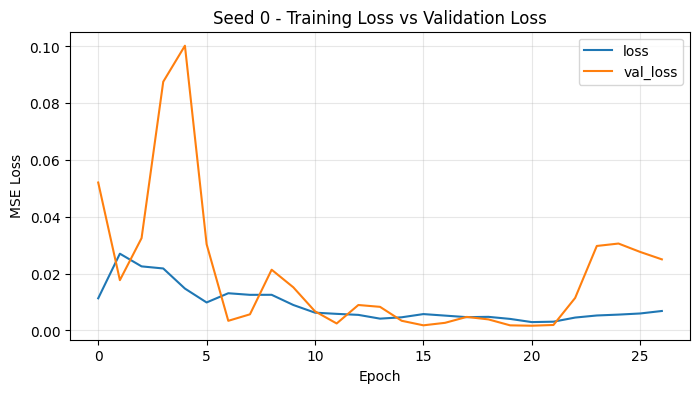

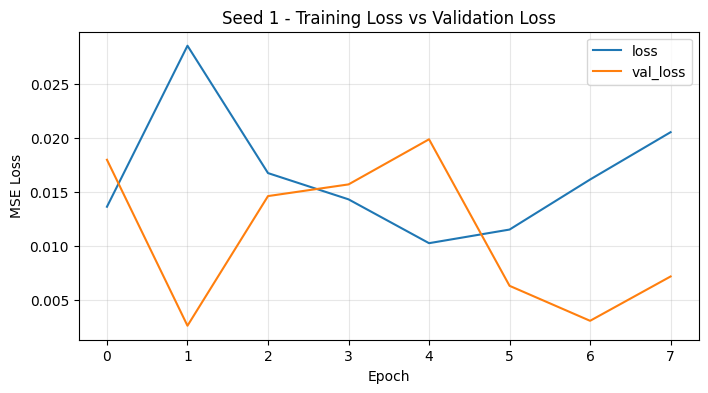

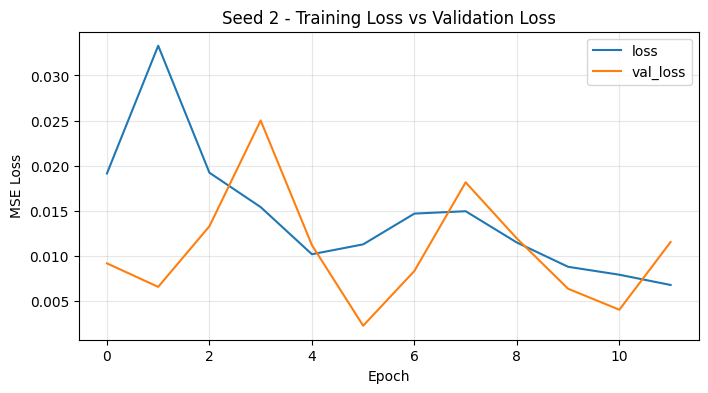

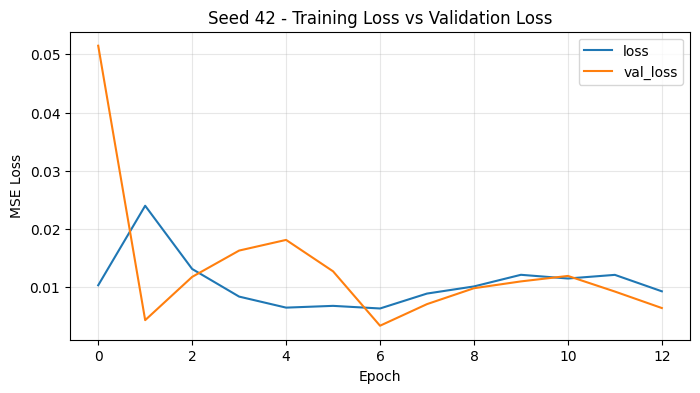

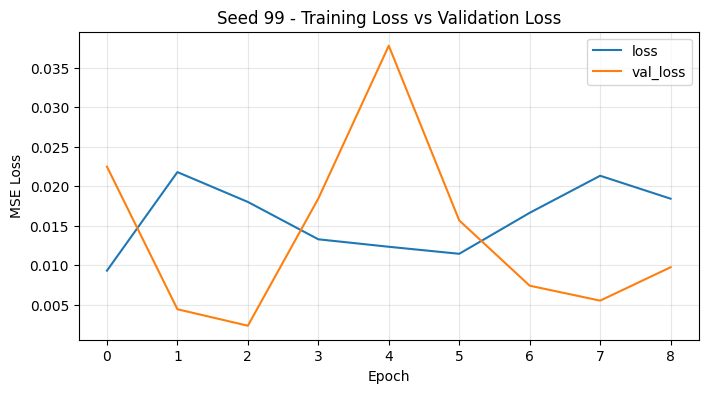

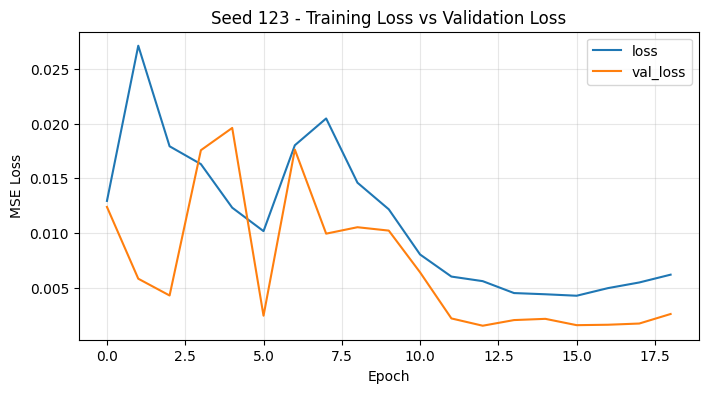

In [ ]:
# =========================
# 18) Plot Every Per-Seed Loss vs Val_Loss
# =========================
for seed in FINAL_SEEDS:
    history = seed_histories[seed]

    plt.figure(figsize=(8, 4))
    plt.plot(history.history["loss"], label="loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.title(f"Seed {seed} - Training Loss vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

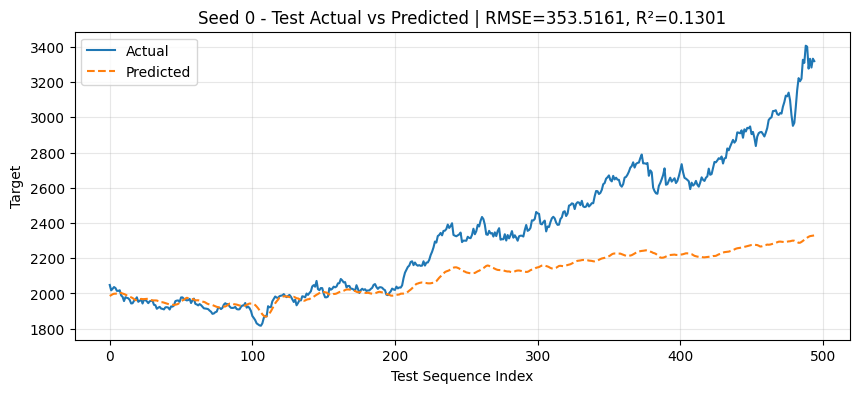

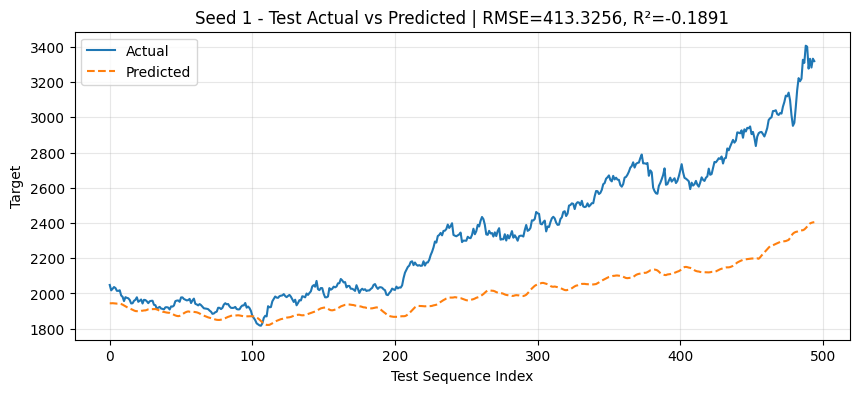

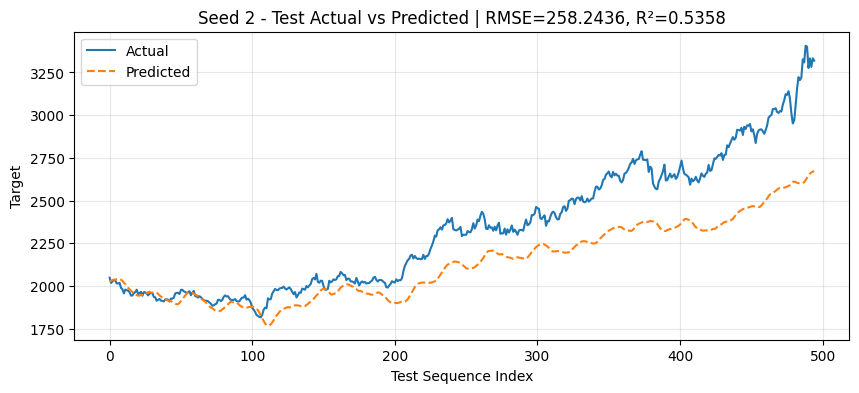

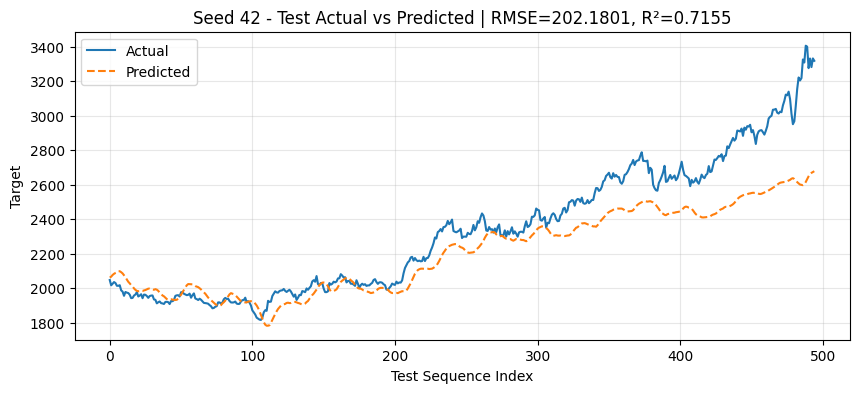

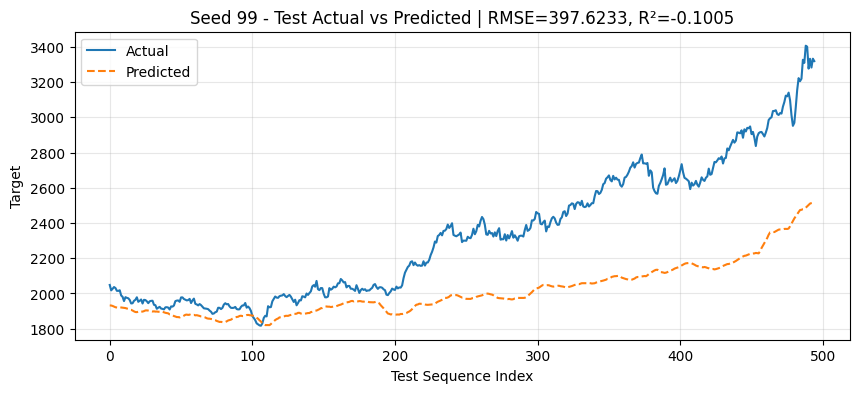

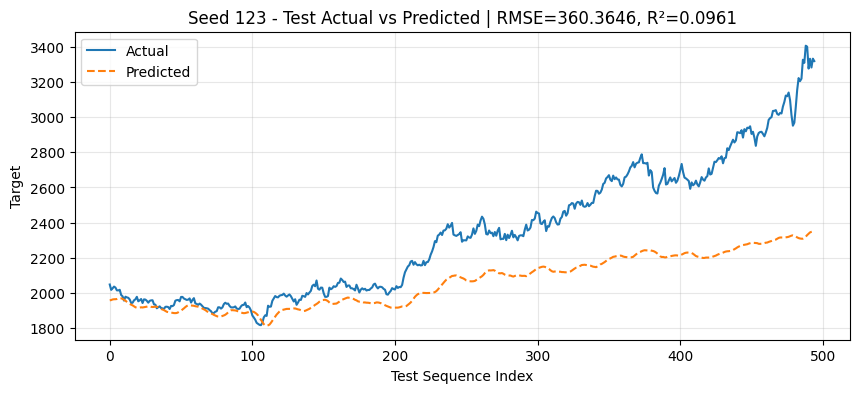

In [ ]:
# =========================
# 19) Plot Every Per-Seed Predicted vs Actual on df_test
# =========================
for seed in FINAL_SEEDS:
    y_true_test = seed_predictions[seed]["y_true_test"]
    y_pred_test = seed_predictions[seed]["y_pred_test"]

    rmse = np.sqrt(mean_squared_error(y_true_test, y_pred_test))
    r2 = r2_score(y_true_test, y_pred_test)

    plt.figure(figsize=(10, 4))
    plt.plot(y_true_test, label="Actual")
    plt.plot(y_pred_test, label="Predicted", linestyle="--")
    plt.title(f"Seed {seed} - Test Actual vs Predicted | RMSE={rmse:.4f}, R²={r2:.4f}")
    plt.xlabel("Test Sequence Index")
    plt.ylabel("Target")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [ ]:
# =========================
# 20) Optional: Save Final Reports
# =========================
bayes_report_df.to_csv("bayesian_walkforward_report.csv", index=False)
final_results_df.to_csv("final_seed_results.csv", index=False)

print("Saved:")
print("- bayesian_walkforward_report.csv")
print("- final_seed_results.csv")